In [1]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate,PromptTemplate
from langchain_core.output_parsers import StrOutputParser
import streamlit as st 
import os 
import sys
sys.path.insert(1, r'D:\Notebooks\LLM\env')
from enviorment import load_env
import os 
from langchain_google_genai import ChatGoogleGenerativeAI
load_env()
from langchain_community.tools.tavily_search import TavilySearchResults
from typing import TypedDict,Annotated,Literal
from pydantic import BaseModel, Field
import operator
from langgraph.graph import StateGraph,START, END,MessagesState

from langgraph.types import Command
from langgraph.checkpoint.memory import InMemorySaver
# model=ChatGoogleGenerativeAI(
#     model="gemini-2.5-flash-lite",   # or gemini-2.0-pro, 1.5-pro, etc.
#     temperature=0.2)
#from langchain_core.messages.utils import trim_messages,count_tokens_approximately
model=ChatOpenAI()

c:\Users\Dharmendra Vartika\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from langchain.messages import RemoveMessage
from langchain_core.messages import HumanMessage

In [3]:
class summary_state(MessagesState):
    summary :str

In [4]:
def call_model(state:summary_state):
    messages=[]
    if state['summary']:
        messages.append({'role':'system','content':f'conversational memory:\n {state['summary']}'})
    messages.extend(state['messages'])
    response =model.invoke(messages)
    return {"messages":[response]}

In [5]:
def summary_node(state:summary_state):
    existing_summary=state['summary']
    if existing_summary:
        promt=f"Existing summary is {existing_summary}\n, extend the summary using the new conversation above"
    else:
        promt='summarise the conversation above'
    messge_for_sumamry=state['messages'] +[HumanMessage(content=promt)]
    result=model.invoke(messge_for_sumamry)
    #msg=state["messages"]
 
    to_remove=state["messages"][:-2]
    return ({'summary':result.content,'messages':[RemoveMessage(id=m.id) for m in to_remove]})

In [6]:
def should_summarzise(state:summary_state):
     check=len(state['messages'])>6
     if check:
          return 'summary_node'
     else:
          END


In [11]:
def should_summarzise_backup(state:summary_state):
     return len(state['messages'])>6
    #  if check:
    #       return 'summary'
    #  else:
    #       END


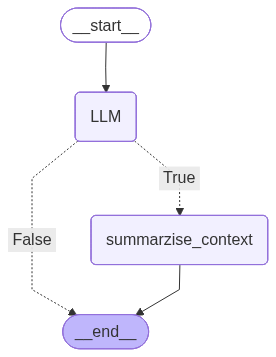

In [12]:
graph=StateGraph(summary_state)
checkpointer=InMemorySaver()
graph.add_node('LLM',call_model)
graph.add_node('summarzise_context',summary_node)
graph.add_conditional_edges('LLM',should_summarzise_backup,{True:'summarzise_context',False:END})
#graph.add_conditional_edges('LLM',should_summarzise)
graph.add_edge(START,'LLM')
#graph.add_edge('chat','summary')
graph.add_edge('summarzise_context',END)
workflow=graph.compile(checkpointer=checkpointer)
workflow

In [13]:
initial_stage={'messages':[{'role':'user','content':'what is data science'}],'summary':''}
thread = {"configurable": {"thread_id": "1"}}
workflow.invoke(initial_stage,config=thread) 

{'messages': [HumanMessage(content='what is data science', additional_kwargs={}, response_metadata={}, id='11fe264e-2da0-41f9-b50d-2a5fdb5422ad'),
  AIMessage(content='Data science is a multidisciplinary field that uses scientific methods, processes, algorithms, and systems to extract knowledge and insights from structured and unstructured data. It combines principles from statistics, computer science, machine learning, and data analysis to analyze, interpret, and visualize complex data sets. Data scientists use programming languages, statistical techniques, and various tools to clean, preprocess, and analyze data to uncover valuable insights that can inform business decisions, solve problems, and drive innovation.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 94, 'prompt_tokens': 11, 'total_tokens': 105, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens':

In [14]:
initial_stage={'messages':[{'role':'user','content':'what is data enginerring'}]}
thread = {"configurable": {"thread_id": "1"}}
workflow.invoke(initial_stage,config=thread) 

{'messages': [HumanMessage(content='what is data science', additional_kwargs={}, response_metadata={}, id='11fe264e-2da0-41f9-b50d-2a5fdb5422ad'),
  AIMessage(content='Data science is a multidisciplinary field that uses scientific methods, processes, algorithms, and systems to extract knowledge and insights from structured and unstructured data. It combines principles from statistics, computer science, machine learning, and data analysis to analyze, interpret, and visualize complex data sets. Data scientists use programming languages, statistical techniques, and various tools to clean, preprocess, and analyze data to uncover valuable insights that can inform business decisions, solve problems, and drive innovation.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 94, 'prompt_tokens': 11, 'total_tokens': 105, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens':

In [15]:
initial_stage={'messages':[{'role':'user','content':'what is data'}]}
thread = {"configurable": {"thread_id": "1"}}
workflow.invoke(initial_stage,config=thread) 

{'messages': [HumanMessage(content='what is data science', additional_kwargs={}, response_metadata={}, id='11fe264e-2da0-41f9-b50d-2a5fdb5422ad'),
  AIMessage(content='Data science is a multidisciplinary field that uses scientific methods, processes, algorithms, and systems to extract knowledge and insights from structured and unstructured data. It combines principles from statistics, computer science, machine learning, and data analysis to analyze, interpret, and visualize complex data sets. Data scientists use programming languages, statistical techniques, and various tools to clean, preprocess, and analyze data to uncover valuable insights that can inform business decisions, solve problems, and drive innovation.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 94, 'prompt_tokens': 11, 'total_tokens': 105, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens':

In [16]:
initial_stage={'messages':[{'role':'user','content':'what is AI'}]}
thread = {"configurable": {"thread_id": "1"}}
workflow.invoke(initial_stage,config=thread) 

{'messages': [HumanMessage(content='what is AI', additional_kwargs={}, response_metadata={}, id='6d88779e-2604-450c-be49-5c587465040b'),
  AIMessage(content='AI, or Artificial Intelligence, is a branch of computer science that aims to create intelligent machines that can simulate human intelligence and perform tasks that typically require human intelligence. AI involves the development of algorithms, models, and systems that can learn from data, adapt to new situations, and make decisions or predictions based on that information.\n\nThere are various subfields of AI, including machine learning, deep learning, natural language processing, computer vision, and robotics. Machine learning, a subset of AI, focuses on developing algorithms that enable machines to learn from and make predictions or decisions based on data without being explicitly programmed.\n\nAI technologies are used in a wide range of applications, including speech recognition, image recognition, recommendation systems, au

In [17]:
initial_stage={'messages':[{'role':'user','content':'what is light'}]}
thread = {"configurable": {"thread_id": "1"}}
workflow.invoke(initial_stage,config=thread) 

{'messages': [HumanMessage(content='what is AI', additional_kwargs={}, response_metadata={}, id='6d88779e-2604-450c-be49-5c587465040b'),
  AIMessage(content='AI, or Artificial Intelligence, is a branch of computer science that aims to create intelligent machines that can simulate human intelligence and perform tasks that typically require human intelligence. AI involves the development of algorithms, models, and systems that can learn from data, adapt to new situations, and make decisions or predictions based on that information.\n\nThere are various subfields of AI, including machine learning, deep learning, natural language processing, computer vision, and robotics. Machine learning, a subset of AI, focuses on developing algorithms that enable machines to learn from and make predictions or decisions based on data without being explicitly programmed.\n\nAI technologies are used in a wide range of applications, including speech recognition, image recognition, recommendation systems, au

In [70]:
initial_stage={'messages':[{'role':'user','content':'my name is Dharmendra'}]}
thread = {"configurable": {"thread_id": "1"}}
workflow.invoke(initial_stage,config=thread) 

{'messages': [HumanMessage(content='what is AI', additional_kwargs={}, response_metadata={}, id='48f471af-babb-429d-a9e0-6b589599f69c'),
  AIMessage(content='AI, or artificial intelligence, is a branch of computer science that focuses on the development of intelligent machines that can perform tasks and make decisions that typically require human intelligence. AI systems are designed to simulate human thinking and behavior, enabling them to learn from data, recognize patterns, solve problems, and adapt to new situations. AI technologies include machine learning, neural networks, natural language processing, computer vision, robotics, and expert systems. AI has a wide range of applications across various industries, such as healthcare, finance, transportation, and entertainment, and is continually evolving to improve efficiency, productivity, and decision-making processes.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 122, 'prompt_tokens'

In [71]:
initial_stage={'messages':[{'role':'user','content':'what is physics'}]}
thread = {"configurable": {"thread_id": "1"}}
workflow.invoke(initial_stage,config=thread) 

{'messages': [HumanMessage(content='what is physics', additional_kwargs={}, response_metadata={}, id='df833986-5802-47d2-b688-5499b02df9b9'),
  AIMessage(content='Physics is the scientific study of matter, energy, and the fundamental forces that govern the interactions between them. It seeks to understand the natural world and how it functions by observing and analyzing the behavior of objects and particles at different scales, from the subatomic level to the cosmic scale. Physics encompasses various subfields, such as mechanics, thermodynamics, electromagnetism, optics, quantum physics, and relativity, each focusing on specific aspects of the physical universe. Physicists use mathematical models, theories, and experiments to describe and predict the behavior of physical systems, leading to advancements in technology, engineering, and our overall understanding of the universe.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 129, 'prompt_to

In [72]:
initial_stage={'messages':[{'role':'user','content':'what is my name'}]}
thread = {"configurable": {"thread_id": "1"}}
workflow.invoke(initial_stage,config=thread) 

{'messages': [HumanMessage(content='what is physics', additional_kwargs={}, response_metadata={}, id='df833986-5802-47d2-b688-5499b02df9b9'),
  AIMessage(content='Physics is the scientific study of matter, energy, and the fundamental forces that govern the interactions between them. It seeks to understand the natural world and how it functions by observing and analyzing the behavior of objects and particles at different scales, from the subatomic level to the cosmic scale. Physics encompasses various subfields, such as mechanics, thermodynamics, electromagnetism, optics, quantum physics, and relativity, each focusing on specific aspects of the physical universe. Physicists use mathematical models, theories, and experiments to describe and predict the behavior of physical systems, leading to advancements in technology, engineering, and our overall understanding of the universe.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 129, 'prompt_to